# Variational Autoencoders (VAE) From Scratch

## 1. Why This Notebook Comes After Autoencoders

In the earlier **Autoencoders** portfolio section, an encoder learned a compact latent representation and a decoder reconstructed the input.

A standard autoencoder is mainly a **reconstruction model**. It does not automatically guarantee that arbitrary points in the latent space decode into meaningful new samples.

A **Variational Autoencoder (VAE)** changes this idea. Instead of mapping each input to one fixed latent vector, the encoder learns a **probability distribution** for the latent representation.

This notebook develops that idea from the beginning and then builds a complete VAE using PyTorch.

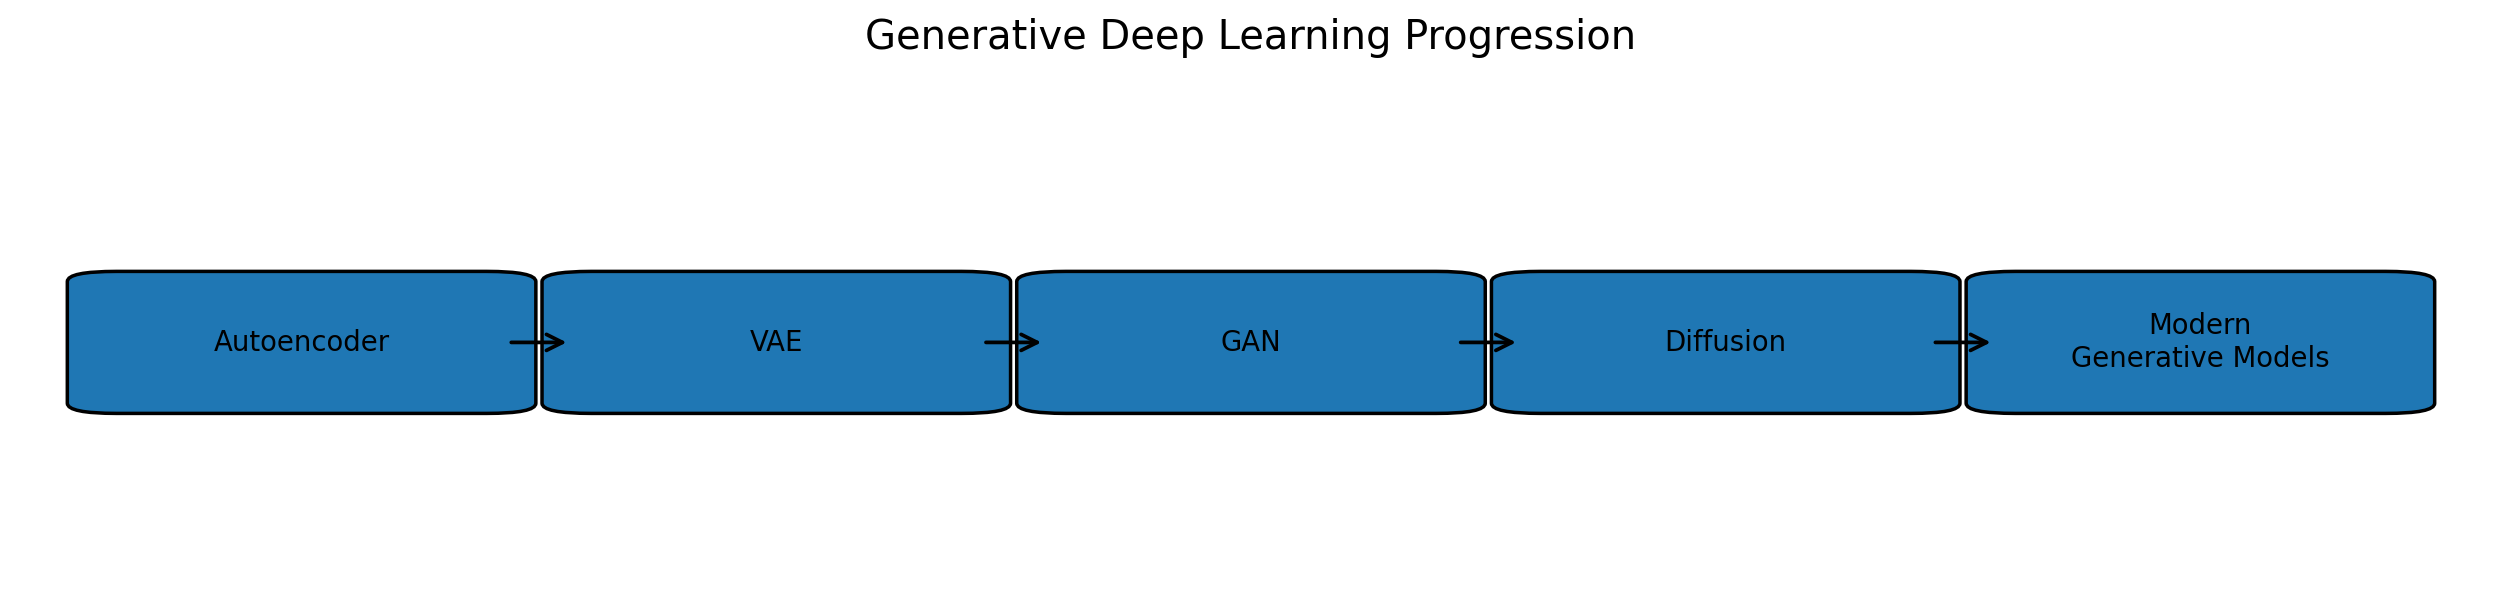

The progression in this folder is:

**deterministic representation learning → probabilistic generation → adversarial generation → diffusion-based generation**

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- distinguish discriminative and generative learning,
- explain the difference between an Autoencoder and a VAE,
- interpret the mean and log-variance produced by a VAE encoder,
- explain the reparameterization trick,
- understand reconstruction loss and KL-divergence,
- derive the practical VAE objective from the ELBO idea,
- build a VAE from scratch with PyTorch,
- train it on MNIST,
- visualize a two-dimensional latent space,
- generate new images by sampling from the latent prior,
- interpolate between latent points,
- explain the strengths and limitations of VAEs.

## 3. Discriminative vs Generative Learning

A discriminative model usually learns a relationship such as:

$$
P(y \mid x)
$$

For example, an image classifier learns to predict a digit label from an image.

A generative model tries to learn the structure of the data distribution itself. Once the distribution has been learned, we can **sample new data** from the learned representation.

For image generation, the goal is no longer only:

> What class does this image belong to?

Instead, we also ask:

> Can the model learn enough about the distribution of images to create new plausible examples?

## 4. From Autoencoder to Variational Autoencoder

A deterministic autoencoder uses:

$$
x \rightarrow z \rightarrow \hat{x}
$$

where one input \(x\) maps to one latent representation \(z\).

A VAE instead learns a latent distribution:

$$
q_\phi(z \mid x)
$$

For a common Gaussian VAE, the encoder predicts:

$$
\mu(x)
$$

and

$$
\log \sigma^2(x)
$$

The latent vector is then sampled from that learned distribution.

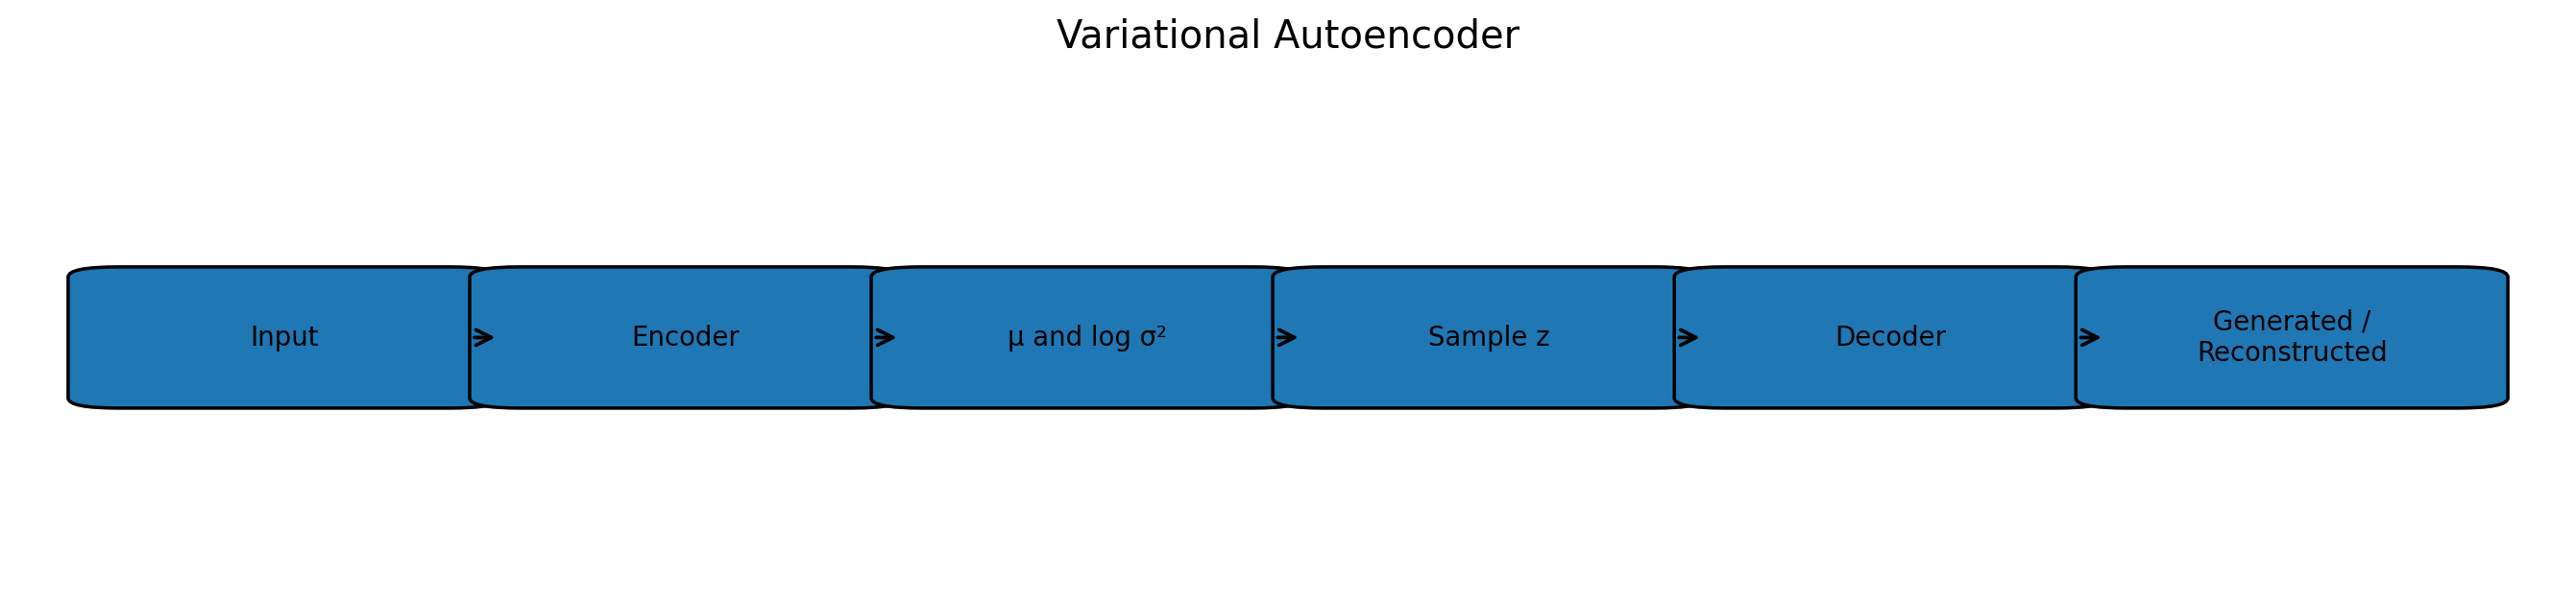

## 5. A Small Probability Example Before the Neural Network

Before building a VAE, first observe what it means to sample from a Gaussian distribution.

We will create samples from a standard normal distribution:

$$
z \sim \mathcal{N}(0, 1)
$$
This is also the prior distribution commonly used by a basic VAE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

number_of_samples = 5000

samples = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=number_of_samples
)

print("Sample array shape:")
print(samples.shape)

print()

print("Sample mean:")
print(samples.mean())

print()

print("Sample standard deviation:")
print(samples.std())

Sample array shape:
(5000,)

Sample mean:
0.005601930087572765

Sample standard deviation:
0.996380175855159


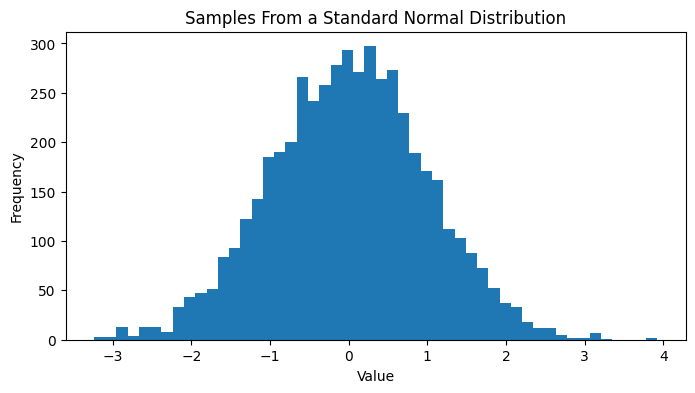

In [2]:
plt.figure(figsize=(8, 4))

plt.hist(
    samples,
    bins=50
)

plt.title("Samples From a Standard Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.show()

The samples are not identical, but they come from one well-defined probability distribution.

A VAE uses the same idea at the latent level: instead of assigning each input to exactly one latent point, it learns parameters describing a latent distribution.

## 6. Mean and Log-Variance

A Gaussian distribution can be described using a mean \(\mu\) and variance \(\sigma^2\).

Why do VAEs often predict **log-variance** instead of variance directly?

The variance must be positive. A neural network can output any real number, but after exponentiating log-variance we always obtain a positive value:

$$
\sigma^2 = \exp(\log \sigma^2)
$$

and therefore:

$$
\sigma = \exp\left(\frac{1}{2}\log \sigma^2\right)
$$

In [3]:
mu = 1.5
log_variance = -0.7

variance = np.exp(log_variance)

standard_deviation = np.exp(
    0.5 * log_variance
)

print("Mean:")
print(mu)

print()

print("Log variance:")
print(log_variance)

print()

print("Variance:")
print(variance)

print()

print("Standard deviation:")
print(standard_deviation)

Mean:
1.5

Log variance:
-0.7

Variance:
0.4965853037914095

Standard deviation:
0.7046880897187134


## 7. The Reparameterization Trick

Sampling directly from a distribution appears to interrupt ordinary gradient-based training.

The VAE rewrites the sample as:

$$
z = \mu + \sigma \odot \epsilon
$$

where:

$$
\epsilon \sim \mathcal{N}(0, I)
$$

Now the random part is isolated in $\epsilon$, while $\mu$ and $\sigma$ remain differentiable functions of the encoder parameters.

This is called the **reparameterization trick**.

In [4]:
np.random.seed(7)

mu = 2.0
standard_deviation = 0.5

epsilon = np.random.normal(
    loc=0.0,
    scale=1.0
)

z = mu + standard_deviation * epsilon

print("Random epsilon:")
print(epsilon)

print()

print("Latent sample z:")
print(z)

Random epsilon:
1.690525703800356

Latent sample z:
2.845262851900178


## 8. The VAE Objective

A VAE balances two goals.

### Reconstruction

The decoder should reconstruct the input well.

### Latent regularization

The learned latent distribution should remain close to the prior, usually:

$$
p(z)=\mathcal{N}(0,I)
$$

For a diagonal Gaussian latent distribution, the KL term can be written as:

$$
D_{KL}
=
-\frac{1}{2}
\sum
\left(
1+\log\sigma^2-\mu^2-\sigma^2
\right)
$$

The practical training loss is commonly expressed as:

$$
L_{VAE}
=
L_{\text{reconstruction}}
+
D_{KL}
$$

The deeper probabilistic view is connected to maximizing the **Evidence Lower Bound (ELBO)**.

## 9. Why the KL Term Matters

If we used only reconstruction loss, the latent space could become irregular. Two nearby latent points would not necessarily decode into similar meaningful samples.

The KL term encourages the learned latent distributions to occupy a smoother, organized region around the prior distribution.

This is what makes random latent sampling useful for generation.

## 10. Imports and Reproducibility

We now move from the small manual examples to a complete VAE implementation.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms

torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:")
print(device)

Device:
cpu


## 11. Load and Inspect MNIST

MNIST is used here because its small grayscale images allow us to focus on generative-model mechanics instead of expensive computation.

In [6]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:")
print(len(train_dataset))

print()

print("Test samples:")
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.35MB/s]

Training samples:
60000

Test samples:
10000


In [7]:
image, label = train_dataset[0]

print("Image type:")
print(type(image))

print()

print("Image shape:")
print(image.shape)

print()

print("Label:")
print(label)

print()

print("Minimum pixel value:")
print(image.min().item())

print()

print("Maximum pixel value:")
print(image.max().item())

Image type:
<class 'torch.Tensor'>

Image shape:
torch.Size([1, 28, 28])

Label:
5

Minimum pixel value:
0.0

Maximum pixel value:
1.0


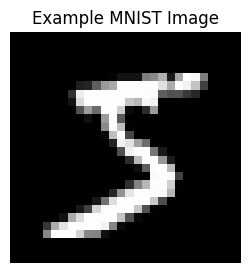

In [8]:
plt.figure(figsize=(3, 3))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    "Example MNIST Image"
)

plt.axis("off")

plt.show()

## 12. Create DataLoaders

In [9]:
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Number of training batches:")
print(len(train_loader))

print()

print("Number of test batches:")
print(len(test_loader))

Number of training batches:
469

Number of test batches:
79


## 13. Inspect One Batch

The VAE will treat each 28 × 28 image as a vector of 784 values in this first implementation.

In [10]:
images, labels = next(iter(train_loader))

print("Batch image shape:")
print(images.shape)

print()

print("Batch label shape:")
print(labels.shape)

Batch image shape:
torch.Size([128, 1, 28, 28])

Batch label shape:
torch.Size([128])


In [11]:
flattened_images = images.view(
    images.size(0),
    -1
)

print("Flattened batch shape:")
print(flattened_images.shape)

Flattened batch shape:
torch.Size([128, 784])


## 14. Define the VAE Architecture

To make the latent space directly visualizable, we use:

```text
latent_dimension = 2
```

The encoder produces **two vectors** for every image:

- latent mean,
- latent log-variance.

The decoder receives one sampled latent vector and reconstructs the image.

In [12]:
input_dimension = 28 * 28
hidden_dimension = 256
latent_dimension = 2

print("Input dimension:")
print(input_dimension)

print()

print("Hidden dimension:")
print(hidden_dimension)

print()

print("Latent dimension:")
print(latent_dimension)

Input dimension:
784

Hidden dimension:
256

Latent dimension:
2


In [13]:
class VariationalAutoencoder(nn.Module):

    def __init__(
        self,
        input_dimension,
        hidden_dimension,
        latent_dimension
    ):
        super().__init__()

        self.encoder_hidden = nn.Linear(
            input_dimension,
            hidden_dimension
        )

        self.encoder_mu = nn.Linear(
            hidden_dimension,
            latent_dimension
        )

        self.encoder_log_variance = nn.Linear(
            hidden_dimension,
            latent_dimension
        )

        self.decoder_hidden = nn.Linear(
            latent_dimension,
            hidden_dimension
        )

        self.decoder_output = nn.Linear(
            hidden_dimension,
            input_dimension
        )


    def encode(self, x):

        hidden = self.encoder_hidden(x)

        hidden = F.relu(hidden)

        mu = self.encoder_mu(hidden)

        log_variance = self.encoder_log_variance(hidden)

        return mu, log_variance


    def reparameterize(
        self,
        mu,
        log_variance
    ):

        standard_deviation = torch.exp(
            0.5 * log_variance
        )

        epsilon = torch.randn_like(
            standard_deviation
        )

        z = mu + standard_deviation * epsilon

        return z


    def decode(self, z):

        hidden = self.decoder_hidden(z)

        hidden = F.relu(hidden)

        reconstruction = self.decoder_output(hidden)

        reconstruction = torch.sigmoid(
            reconstruction
        )

        return reconstruction


    def forward(self, x):

        mu, log_variance = self.encode(x)

        z = self.reparameterize(
            mu,
            log_variance
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, log_variance

## 15. Instantiate and Inspect the Model

In [14]:
model = VariationalAutoencoder(
    input_dimension=input_dimension,
    hidden_dimension=hidden_dimension,
    latent_dimension=latent_dimension
)

model = model.to(device)

print(model)

VariationalAutoencoder(
  (encoder_hidden): Linear(in_features=784, out_features=256, bias=True)
  (encoder_mu): Linear(in_features=256, out_features=2, bias=True)
  (encoder_log_variance): Linear(in_features=256, out_features=2, bias=True)
  (decoder_hidden): Linear(in_features=2, out_features=256, bias=True)
  (decoder_output): Linear(in_features=256, out_features=784, bias=True)
)


In [15]:
total_parameters = 0

for parameter in model.parameters():
    total_parameters = total_parameters + parameter.numel()

print("Total model parameters:")
print(total_parameters)

Total model parameters:
404244


## 16. Follow One Batch Through the Model

Before training, inspect every important tensor.

In [16]:
images, labels = next(iter(train_loader))

images = images.to(device)

images_flat = images.view(
    images.size(0),
    -1
)

reconstruction, mu, log_variance = model(
    images_flat
)

print("Input shape:")
print(images_flat.shape)

print()

print("Mean shape:")
print(mu.shape)

print()

print("Log-variance shape:")
print(log_variance.shape)

print()

print("Reconstruction shape:")
print(reconstruction.shape)

Input shape:
torch.Size([128, 784])

Mean shape:
torch.Size([128, 2])

Log-variance shape:
torch.Size([128, 2])

Reconstruction shape:
torch.Size([128, 784])


## 17. Define the VAE Loss Explicitly

We keep the reconstruction and KL components separate so that we can observe what each part contributes.

In [17]:
def calculate_vae_loss(
    reconstruction,
    target,
    mu,
    log_variance
):

    reconstruction_loss = F.binary_cross_entropy(
        reconstruction,
        target,
        reduction="sum"
    )

    kl_divergence = -0.5 * torch.sum(
        1
        + log_variance
        - mu.pow(2)
        - log_variance.exp()
    )

    total_loss = (
        reconstruction_loss
        + kl_divergence
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_divergence
    )

In [18]:
total_loss, reconstruction_loss, kl_loss = calculate_vae_loss(
    reconstruction,
    images_flat,
    mu,
    log_variance
)

print("Total loss:")
print(total_loss.item())

print()

print("Reconstruction loss:")
print(reconstruction_loss.item())

print()

print("KL-divergence loss:")
print(kl_loss.item())

Total loss:
70457.21875

Reconstruction loss:
70456.390625

KL-divergence loss:
0.8312442302703857


## 18. Train the VAE

The loop is kept explicit so the learning process remains visible.

For a quick Colab run, a few epochs are enough to verify the pipeline. For final portfolio results, you can increase the number of epochs.

In [19]:
learning_rate = 0.001
number_of_epochs = 8

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

training_total_losses = []
training_reconstruction_losses = []
training_kl_losses = []

In [20]:
for epoch in range(number_of_epochs):

    model.train()

    epoch_total_loss = 0.0
    epoch_reconstruction_loss = 0.0
    epoch_kl_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        images_flat = images.view(
            images.size(0),
            -1
        )

        optimizer.zero_grad()

        reconstruction, mu, log_variance = model(
            images_flat
        )

        total_loss, reconstruction_loss, kl_loss = calculate_vae_loss(
            reconstruction,
            images_flat,
            mu,
            log_variance
        )

        total_loss.backward()

        optimizer.step()

        epoch_total_loss = epoch_total_loss + total_loss.item()

        epoch_reconstruction_loss = (
            epoch_reconstruction_loss
            + reconstruction_loss.item()
        )

        epoch_kl_loss = (
            epoch_kl_loss
            + kl_loss.item()
        )

    dataset_size = len(train_loader.dataset)

    average_total_loss = (
        epoch_total_loss
        / dataset_size
    )

    average_reconstruction_loss = (
        epoch_reconstruction_loss
        / dataset_size
    )

    average_kl_loss = (
        epoch_kl_loss
        / dataset_size
    )

    training_total_losses.append(
        average_total_loss
    )

    training_reconstruction_losses.append(
        average_reconstruction_loss
    )

    training_kl_losses.append(
        average_kl_loss
    )

    print(
        "Epoch:",
        epoch + 1,
        "| Total:",
        round(average_total_loss, 4),
        "| Reconstruction:",
        round(average_reconstruction_loss, 4),
        "| KL:",
        round(average_kl_loss, 4)
    )

Epoch: 1 | Total: 194.966 | Reconstruction: 187.994 | KL: 6.972
Epoch: 2 | Total: 169.7509 | Reconstruction: 164.4423 | KL: 5.3087
Epoch: 3 | Total: 165.06 | Reconstruction: 159.7517 | KL: 5.3083
Epoch: 4 | Total: 162.7172 | Reconstruction: 157.381 | KL: 5.3362
Epoch: 5 | Total: 161.198 | Reconstruction: 155.831 | KL: 5.367
Epoch: 6 | Total: 160.0196 | Reconstruction: 154.5883 | KL: 5.4313
Epoch: 7 | Total: 159.0615 | Reconstruction: 153.5916 | KL: 5.4699
Epoch: 8 | Total: 158.2502 | Reconstruction: 152.7422 | KL: 5.508


## 19. Plot the Loss Components

A VAE should not be interpreted using total loss alone. Reconstruction quality and latent regularization represent different objectives.

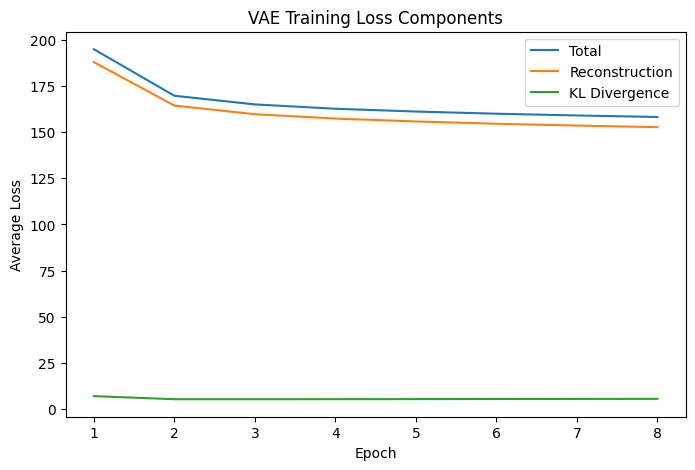

In [21]:
epochs = range(
    1,
    number_of_epochs + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_total_losses,
    label="Total"
)

plt.plot(
    epochs,
    training_reconstruction_losses,
    label="Reconstruction"
)

plt.plot(
    epochs,
    training_kl_losses,
    label="KL Divergence"
)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("VAE Training Loss Components")
plt.legend()

plt.show()

## 20. Compare Original and Reconstructed Images

In [22]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

images_flat = images.view(
    images.size(0),
    -1
)

with torch.no_grad():

    reconstruction, mu, log_variance = model(
        images_flat
    )

reconstructed_images = reconstruction.view(
    -1,
    1,
    28,
    28
)

images = images.cpu()
reconstructed_images = reconstructed_images.cpu()

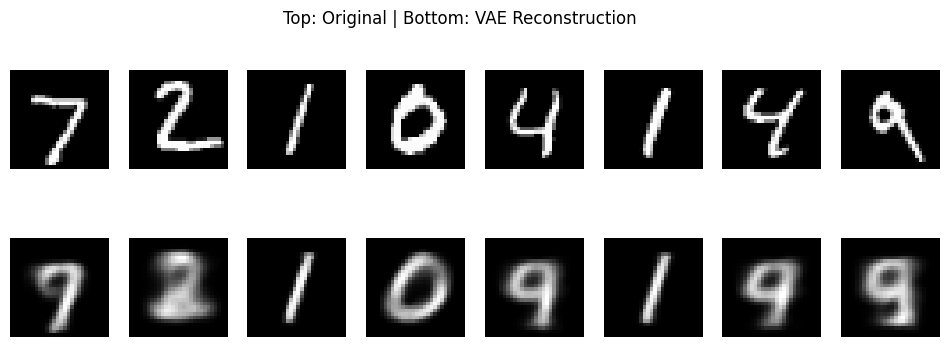

In [23]:
number_to_show = 8

plt.figure(figsize=(12, 4))

for index in range(number_to_show):

    plt.subplot(
        2,
        number_to_show,
        index + 1
    )

    plt.imshow(
        images[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

    plt.subplot(
        2,
        number_to_show,
        number_to_show + index + 1
    )

    plt.imshow(
        reconstructed_images[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Top: Original | Bottom: VAE Reconstruction"
)

plt.show()

## 21. Visualize the Two-Dimensional Latent Space

Because the latent dimension is two, we can directly plot the encoded means.

The labels are used only for visualization. They are **not** used to train the VAE.

In [24]:
model.eval()

all_mu = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        images_flat = images.view(
            images.size(0),
            -1
        )

        mu, log_variance = model.encode(
            images_flat
        )

        all_mu.append(
            mu.cpu()
        )

        all_labels.append(
            labels
        )

all_mu = torch.cat(
    all_mu,
    dim=0
)

all_labels = torch.cat(
    all_labels,
    dim=0
)

print("Latent mean shape:")
print(all_mu.shape)

Latent mean shape:
torch.Size([10000, 2])


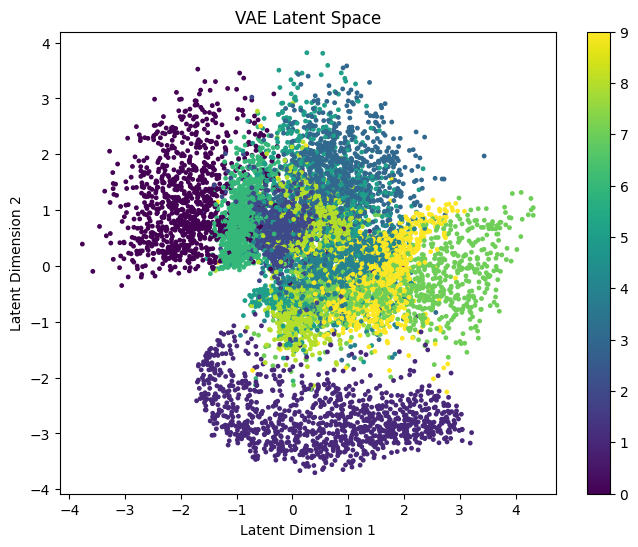

In [25]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    all_mu[:, 0],
    all_mu[:, 1],
    c=all_labels,
    s=6
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space")
plt.colorbar(scatter)

plt.show()

## 22. Generate New Images From Random Latent Samples

This is the key generative step.

We no longer provide an input image.

Instead:

$$
z \sim \mathcal{N}(0,I)
$$

and the decoder converts sampled latent vectors into images.

In [26]:
number_of_generated_images = 16

random_z = torch.randn(
    number_of_generated_images,
    latent_dimension
)

random_z = random_z.to(device)

with torch.no_grad():

    generated = model.decode(
        random_z
    )

generated = generated.view(
    -1,
    1,
    28,
    28
)

generated = generated.cpu()

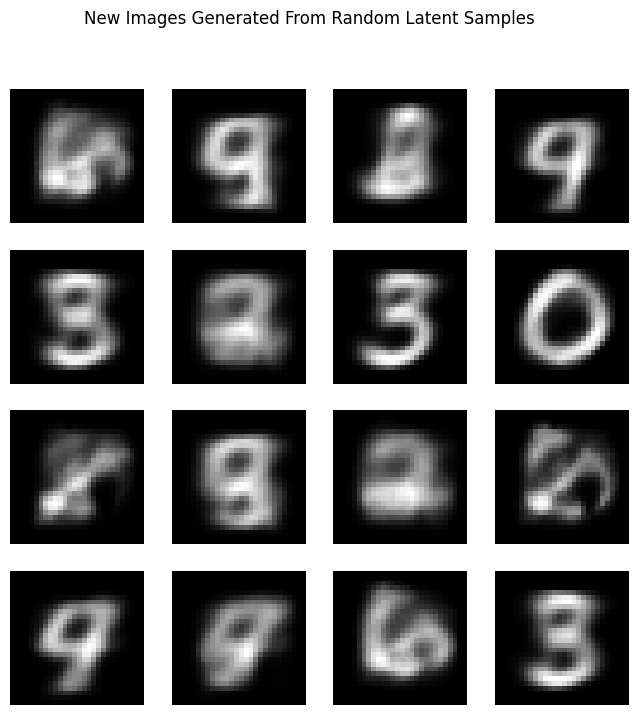

In [27]:
plt.figure(figsize=(8, 8))

for index in range(number_of_generated_images):

    plt.subplot(
        4,
        4,
        index + 1
    )

    plt.imshow(
        generated[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "New Images Generated From Random Latent Samples"
)

plt.show()

## 23. Latent Interpolation

A useful property of a smooth latent space is that we can move gradually between two latent points and decode the intermediate positions.

In [28]:
z_start = torch.tensor(
    [-2.0, -1.0],
    device=device
)

z_end = torch.tensor(
    [2.0, 1.0],
    device=device
)

number_of_steps = 10

interpolation_weights = torch.linspace(
    0.0,
    1.0,
    number_of_steps
)

interpolated_vectors = []

for weight in interpolation_weights:

    z = (
        (1.0 - weight) * z_start
        + weight * z_end
    )

    interpolated_vectors.append(z)

interpolated_vectors = torch.stack(
    interpolated_vectors
)

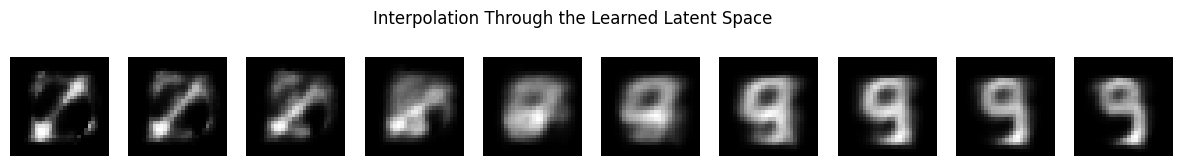

In [29]:
with torch.no_grad():

    interpolated_images = model.decode(
        interpolated_vectors
    )

interpolated_images = interpolated_images.view(
    -1,
    1,
    28,
    28
)

interpolated_images = interpolated_images.cpu()

plt.figure(figsize=(15, 2))

for index in range(number_of_steps):

    plt.subplot(
        1,
        number_of_steps,
        index + 1
    )

    plt.imshow(
        interpolated_images[index].squeeze(),
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Interpolation Through the Learned Latent Space"
)

plt.show()

## 24. Deeper Concept: β-VAE

A useful extension modifies the objective:

$$
L
=
L_{\text{reconstruction}}
+
\beta D_{KL}
$$

When $\beta > 1$, the model places stronger pressure on latent regularization.

This may encourage more organized or disentangled representations, but excessive regularization can reduce reconstruction quality.

A useful portfolio experiment is to compare:

```text
β = 0.1
β = 1.0
β = 4.0
```

while keeping every other setting fixed.

Record:

- reconstruction loss,
- KL loss,
- generated-image quality,
- latent-space organization.

The goal is not simply to identify one "best" β. The goal is to demonstrate the **trade-off between reconstruction and latent regularization**.

## 25. VAE Strengths and Limitations

### Strengths

- principled probabilistic latent representation,
- smooth latent space,
- direct sampling,
- useful for representation learning,
- clear probabilistic interpretation.

### Limitations

- generated images can look blurrier than adversarial or diffusion models,
- the prior assumption may be restrictive,
- reconstruction and regularization objectives compete,
- posterior collapse can occur in stronger decoder architectures.

These limitations motivate other generative approaches.

## 26. Connection to the Next Notebook

The VAE asks:

> Can we learn a smooth latent probability distribution and decode samples from it?

The next model asks a very different question:

> What if a generator learns by trying to fool another neural network?

That leads to **Generative Adversarial Networks (GANs)**.

## 27. Key Takeaways

- A VAE extends an autoencoder from deterministic encoding to probabilistic latent modeling.
- The encoder predicts a mean and log-variance instead of one fixed latent point.
- The reparameterization trick allows stochastic sampling while preserving gradient-based training.
- Reconstruction loss measures output fidelity.
- KL-divergence regularizes the latent distribution toward the prior.
- New samples can be created by sampling from the prior and passing latent vectors through the decoder.
- Latent interpolation helps reveal whether the learned representation is smooth.